The purpose of this notebook is to produce the figure used in the paper to illustrate linear calibration.

In [2]:
import os
import sys
from pathlib import Path
import json
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.model_selection import KFold, ParameterGrid
from scipy.stats import linregress

sys.path.append('..')

from EDA.edautils import plot_deconvolution_results
from syto.deconvolution.evaluation import compute_deconvolution_metrics
from syto.calibration.linear_calibrator import LinearCalibrator
# from EDA.dirichlet_calibration import DirichletCalibrator

%load_ext autoreload
%autoreload 2

In [14]:
# Directory of Dismir + Soft Labels with pooling + PSLS
ROOT_PATH = Path("/staging/leuven/stg_00118/gbw-d-l0154/mnt/data/syto_experiments/mlflow/198121009408531961/1f0aaa3947bb4732a945e76aed3a5864/artifacts/calibration/psls_calibrators_and_predictions")
dismir_lin_cal = LinearCalibrator.load(ROOT_PATH / "linear_calibrator.joblib")
uncalibrated_pred = np.load(ROOT_PATH / "uncalibrated_predictions.npz")
simplex_cal_pred = np.load(ROOT_PATH / "linear_simplex_projection_predictions.npz")

In [22]:
valid_target_prop = np.load("/staging/leuven/stg_00118/methylDL/experiments/target_proportions_valid.npz")["proportions"]
test_target_prop = np.load("/staging/leuven/stg_00118/methylDL/experiments/target_proportions_test.npz")["proportions"]

In [31]:
ctype_names_list = list(json.load(open("/data/leuven/389/vsc38912/Projects/syto/App/labels_dict.json", "r", encoding="utf-8")).values())

In [17]:
cell_idx_max_slope = np.argmax(dismir_lin_cal.slopes)
cell_idx_min_slope = np.argsort(dismir_lin_cal.slopes)[-2]
cell_idx_max_slope, cell_idx_min_slope

(np.int64(11), np.int64(28))

In [23]:
results = {
    "max_slope": {
        "val": {
            "uncalibrated": uncalibrated_pred["val_pred"][:, cell_idx_max_slope],
            "calibrated": simplex_cal_pred["val_pred"][:, cell_idx_max_slope],
        },
        "test": {
            "uncalibrated": uncalibrated_pred["test_pred"][:, cell_idx_max_slope],
            "calibrated": simplex_cal_pred["test_pred"][:, cell_idx_max_slope],
        },
    },
    "min_slope": {
        "val": {
            "uncalibrated": uncalibrated_pred["val_pred"][:, cell_idx_min_slope],
            "calibrated": simplex_cal_pred["val_pred"][:, cell_idx_min_slope],
        },
        "test": {
            "uncalibrated": uncalibrated_pred["test_pred"][:, cell_idx_min_slope],
            "calibrated": simplex_cal_pred["test_pred"][:, cell_idx_min_slope],
        },
    },
}
cell_idx_dict = {
    "max_slope": cell_idx_max_slope,
    "min_slope": cell_idx_min_slope,
}

In [24]:
# Prepare the lines showing the regressed lines
REGRESSION_X = np.linspace(0, 1, 1000)

regression_y = {}
slopes_intercepts_dict = {}
for cell, cell_res in results.items():
    regression_y[cell] = {}
    slopes_intercepts_dict[cell] = {}
    for dataset, dataset_res in cell_res.items():
        regression_y[cell][dataset] = {}
        slopes_intercepts_dict[cell][dataset] = {}
        for calib_status, cell_type_pred in dataset_res.items():
            cell_idx = cell_idx_dict[cell]
            cell_type_true = (
                valid_target_prop[:, cell_idx]
                if dataset == "val"
                else test_target_prop[:, cell_idx]
            )
            slope, intercept, _, _, _ = linregress(cell_type_pred, cell_type_true)
            slopes_intercepts_dict[cell][dataset][calib_status] = (slope, intercept)
            regression_y[cell][dataset][calib_status] = slope * REGRESSION_X + intercept

In [25]:
def subsample_uniform_across_range(values, n, num_bins=100, random_state=None):
    """
    Subsample n indices from the given values, aiming for a uniform distribution across the range [0, 1].
    The values are binned into num_bins equal-width bins, and samples are drawn from each bin proportionally to the number of values in that bin, ensuring a more uniform coverage of the range.
    If there are fewer unique values than n, all indices are returned. The random_state can be used to control reproducibility.
    """
    vals = np.asarray(values).clip(0.0, 1.0)
    m = len(vals)
    if n >= m:
        return np.arange(m, dtype=int)
    bins = np.linspace(0.0, 1.0, num_bins + 1)
    bin_ids = np.digitize(vals, bins, right=True) - 1
    rng = np.random.default_rng(random_state)

    # indices per bin
    idxs_per_bin = [np.where(bin_ids == i)[0] for i in range(num_bins)]
    non_empty = [idxs for idxs in idxs_per_bin if idxs.size > 0]
    if not non_empty:
        return rng.choice(np.arange(m), size=n, replace=False)

    base = n // len(non_empty)
    rem = n % len(non_empty)
    selected = []
    for i, idxs in enumerate(non_empty):
        k = base + (1 if i < rem else 0)
        if k <= 0:
            continue
        if k >= len(idxs):
            selected.extend(idxs.tolist())
        else:
            selected.extend(rng.choice(idxs, size=k, replace=False).tolist())

    # fill/trim to exactly n
    selected = list(dict.fromkeys(selected))  # keep order, unique
    if len(selected) < n:
        remaining = np.setdiff1d(np.arange(m), selected)
        extra = rng.choice(remaining, size=(n - len(selected)), replace=False)
        selected.extend(extra.tolist())
    elif len(selected) > n:
        selected = rng.choice(selected, size=n, replace=False).tolist()

    return np.array(selected, dtype=int)

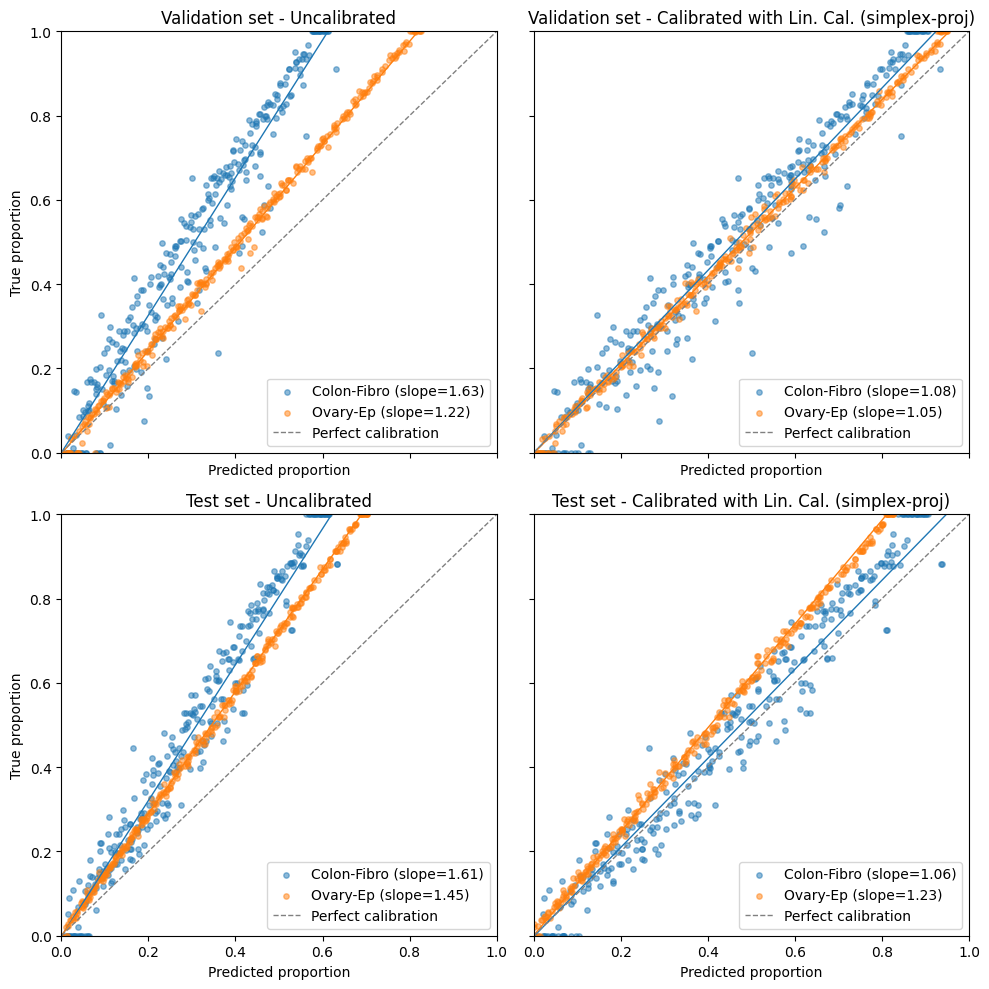

In [33]:
N_SUBSAMPLE = 300

datasets = ["val", "test"]
cols = ["uncalibrated", "calibrated"]
cells = ["max_slope", "min_slope"]
colors = {"max_slope": "C0", "min_slope": "C1"}

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
for i, ds in enumerate(datasets):
    # precompute subsample indices per cell using the uncalibrated predictions so calibrated and uncalibrated use the same indices
    idx_by_cell = {}
    for cell_key in cells:
        uncal_pred = results[cell_key][ds]["uncalibrated"]
        idx_by_cell[cell_key] = subsample_uniform_across_range(
            uncal_pred, N_SUBSAMPLE, random_state=42
        )
    for j, calib in enumerate(cols):
        ax = axes[i, j]
        for k, cell_key in enumerate(cells):
            pred = results[cell_key][ds][calib]
            cell_idx = cell_idx_dict[cell_key]
            true = (
                valid_target_prop[:, cell_idx]
                if ds == "val"
                else test_target_prop[:, cell_idx]
            )
            # use the same indices for calibrated and uncalibrated
            idx = idx_by_cell[cell_key]
            x = pred[idx]
            y = true[idx]
            name = ctype_names_list[cell_idx]
            # regression is computed with all points
            slope, intercept = slopes_intercepts_dict[cell_key][ds][calib]
            # plot
            ax.scatter(
                x,
                y,
                s=15,
                alpha=0.5,
                color=colors[cell_key],
                label=f"{name} (slope={slope:.2f})",
            )
            ax.plot(
                REGRESSION_X,
                regression_y[cell_key][ds][calib],
                color=colors[cell_key],
                lw=1,
            )
        ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Perfect calibration")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Predicted proportion")
        if j == 0:
            ax.set_ylabel("True proportion")
        title_ds = "Validation" if ds == "val" else "Test"
        title_calib = (
            "Uncalibrated"
            if calib == "uncalibrated"
            else "Calibrated with Lin. Cal. (simplex-proj)"
        )
        ax.set_title(f"{title_ds} set - {title_calib}")
        # if i == 0 and j == 1:
        ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../output/neurips_figures/linear_calibration_illustration.pdf")
plt.show()